# Analýza zákazníků

Máme k dispozici seznam zákazníků s jejich osobními informacemi a jejich chováním.

Na trh chceme uvést nový luxusní a drahý výrobek. 

Na které zákazníky máme zaměřit personalizovaný marketing?

# Úkol
- Proveďte základní analýzu dat a jejich vizualizaci
- Proveďte úpravu dat (encoding)
- Vyberte vhodné proměnné, podle kterých půjdou zákazníci segmentovat
- Vytvořte k-mean model s vhodným počtem segmentů
- Vizualizujte model
- Který segment je cílový?

# Načtení dat

In [66]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns  

In [67]:
data=pd.read_csv('../dataset/Mall_Customers.csv')

# Popis  dat
- informace o datech
- náhled na data
- základní statistika
- zobrazení distribuce dat

In [68]:
# - informace o datech
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [69]:
# - náhled na data
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [70]:
# - základní statistika
data.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


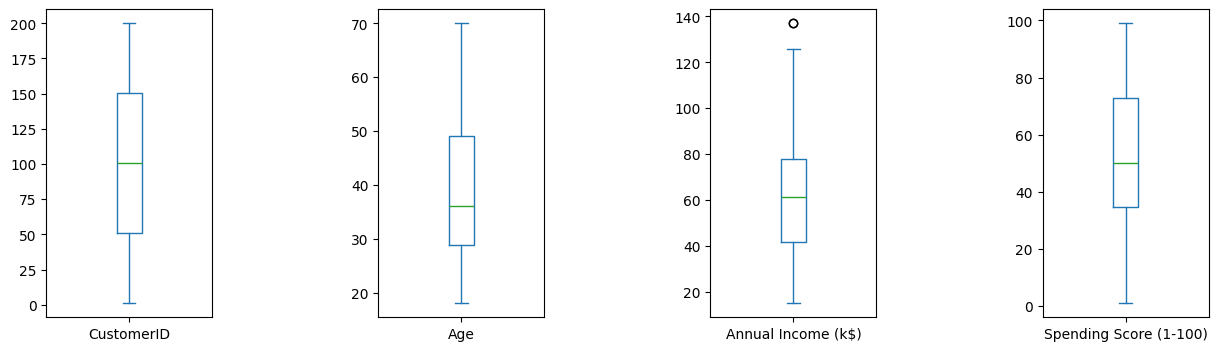

In [72]:
# - zobrazení distribuce dat
data.plot(
    kind='box', 
    subplots=True, 
    sharey=False, 
    figsize=(15, 4)
)
plt.subplots_adjust(wspace=1) 
plt.show()

# Příprava dat
- ošetření NaN hodnot
- encodování textových sloupců

In [73]:
from sklearn import preprocessing

In [74]:
# - ošetření NaN hodnot
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [75]:
label_encoder = preprocessing.LabelEncoder()
data['gender_enc']=label_encoder.fit_transform(data['Gender'])

In [76]:
data=data[['Age','Annual Income (k$)','gender_enc','Spending Score (1-100)']]

# Výběr proměnných
- zobrazení vztahů mezi proměnnými (pairplot)
- hledáme kombinaci proměnných, které lze opticky ropzdělit do skupin
- vytvoření X pouze s těmito sloupci

<Axes: >

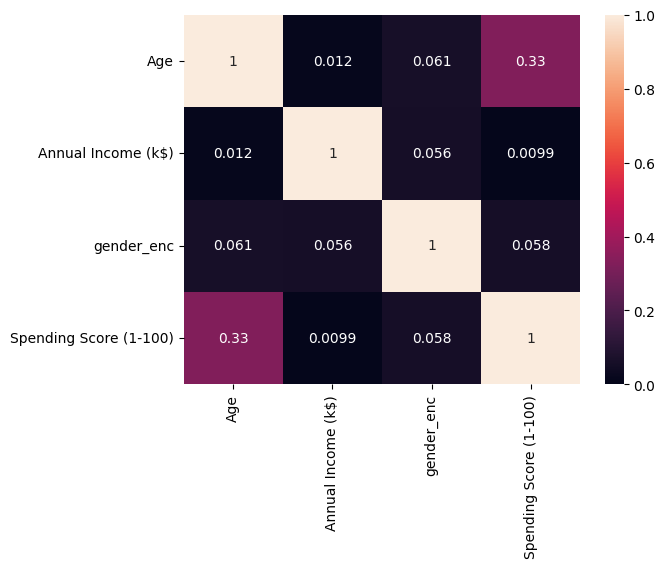

In [77]:
corr=data.corr()
sns.heatmap(corr.abs(), annot=True, vmin=0, vmax=1)

In [78]:
data = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Zjištění parametru modelu k-mean
- vykreslení elbow grafu
- zjištění ideálního počtu clusterů

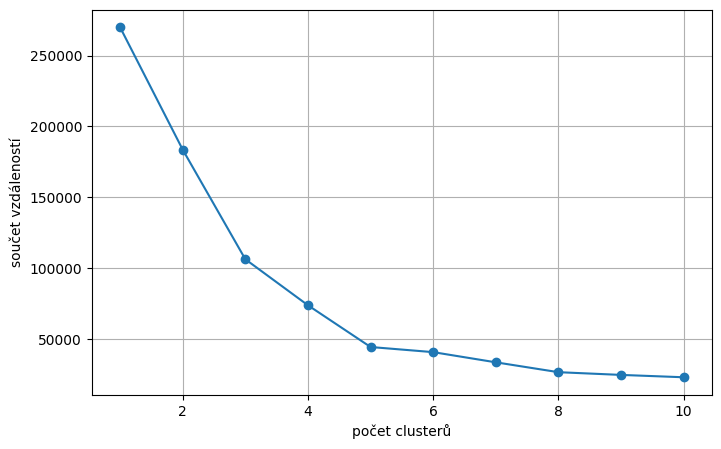

In [79]:
from sklearn.cluster import KMeans

list = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(data)
    list.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1, 11), list, marker='o')
plt.xlabel('počet clusterů')
plt.ylabel('součet vzdáleností')
plt.grid(True)
plt.show()

# k-mean model pro zjištěný počet clusterů
- natrénování modelu
- predikce dat

In [80]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)

kmeans.fit(data)

clusters = kmeans.predict(data)

data['Cluster'] = clusters

# Vizualizace modelu
- vykreslení obarvených skupin grafů

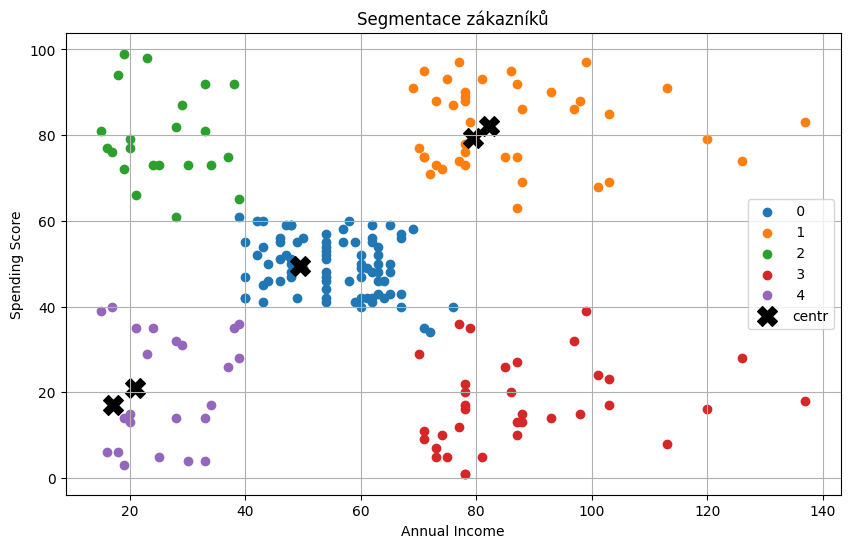

In [85]:
plt.figure(figsize=(10,6))

plt.scatter(data[data['Cluster'] == 0]['Annual Income (k$)'], data[data['Cluster'] == 0]['Spending Score (1-100)'], label=' 0')
plt.scatter(data[data['Cluster'] == 1]['Annual Income (k$)'], data[data['Cluster'] == 1]['Spending Score (1-100)'], label=' 1')
plt.scatter(data[data['Cluster'] == 2]['Annual Income (k$)'], data[data['Cluster'] == 2]['Spending Score (1-100)'], label=' 2')
plt.scatter(data[data['Cluster'] == 3]['Annual Income (k$)'], data[data['Cluster'] == 3]['Spending Score (1-100)'], label=' 3')
plt.scatter(data[data['Cluster'] == 4]['Annual Income (k$)'], data[data['Cluster'] == 4]['Spending Score (1-100)'], label=' 4')

plt.scatter(kmeans.cluster_centers_[:,1], kmeans.cluster_centers_[:,1], s=200, c='black', label='centr', marker='X')

plt.title('Segmentace zákazníků')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.grid(True)
plt.show()

## Výklad modelu
- Popište jednotlivé skupiny
- Na jaké zákazníky se zaměřit?

In [ ]:
# - Popište jednotlivé skupiny

# Modrá (0) – Střední příjem, průměrné útraty, racionální zákazníci.
# Oranžová (1) – Vysoký příjem, vysoké útraty, prémioví zákazníci.
# Zelená (2) – Nízký příjem, vysoké útraty, impulzivní nakupující.
# Červená (3) – Vysoký příjem, nízké útraty, konzervativní zákazníci.
# Fialová (4) – Nízký příjem, nízké útraty, omezený rozpočet.

In [ ]:
# - Na jaké zákazníky se zaměřit?

# Hlavní cílovou skupinou jsou oranžoví zákazníci (vysoký příjem, vysoké útraty). 
# Potenciál má i zelená skupina (nízký příjem, ale vysoké výdaje).
#  Červenou skupinu lze aktivovat lepší nabídkou.